# Session 4: Routing objective — contrail exposure vs fuel

Session 3 compared candidate routes by contrail exposure, using extra
distance as the only operational cost. That made altitude changes look
free. This session adds fuel burn from the Poll–Schumann aircraft
performance model (`pycontrails.models.ps_model.PSFlight`), restricts
cruise to realistic flight levels (FL310–FL380), and defines how routes
are ranked when contrail exposure and fuel pull in opposite directions.

**Setup:** same ERA5 data, endpoints and departure time as Session 3.
5 lateral offsets (0, ±150, ±300 km) × 8 flight levels = 40 routes.
Aircraft: A320, constant true airspeed 230 m/s, constant flight level,
no wind, cruise only (no climb or descent).

**Reference route:** the minimum-fuel candidate, i.e. what would be flown
if contrails were ignored.

In [1]:
from pathlib import Path

pkg = Path("..") / "src" / "contrail_routing"
pkg.mkdir(parents=True, exist_ok=True)
(pkg / "__init__.py").write_text('"""Contrail-aware routing experiments."""\n')
print("Created:", pkg.resolve())

Created: C:\Users\barqb\robust-contrail-routing\src\contrail_routing


Module code now lives in src/contrail_routing/; see that folder for the current version.  
%%writefile ../src/contrail_routing/geometry.py
"""Route geometry: great-circle routes with smooth lateral deviations,
flown at constant speed and constant altitude."""
import numpy as np
import pandas as pd
from pycontrails import Flight

R_EARTH_KM = 6371.0
FT_TO_M = 0.3048


def haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance in km between points given in degrees."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * R_EARTH_KM * np.arcsin(np.sqrt(a))


def flight_level_to_m(flight_level):
    """Pressure altitude in metres for a flight level (FL370 = 37,000 ft)."""
    return flight_level * 100 * FT_TO_M


def lonlat_to_xyz(lon, lat):
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon),
                     np.cos(lat) * np.sin(lon),
                     np.sin(lat)], axis=-1)


def xyz_to_lonlat(v):
    lon = np.degrees(np.arctan2(v[..., 1], v[..., 0]))
    lat = np.degrees(np.arcsin(np.clip(v[..., 2], -1.0, 1.0)))
    return lon, lat


def make_route(origin, destination, offset_km, altitude_m, departure, speed_ms,
               time_step_s=60, name="route", n_shape=400):
    """
    Great-circle route from origin to destination (each (lon, lat) in degrees),
    bent sideways by offset_km * sin(pi * s), s = 0 -> 1 along the route.
    offset_km > 0 bends to the left of travel. Flown at constant speed_ms,
    one point every time_step_s seconds, at constant altitude_m.
    """
    a, b = lonlat_to_xyz(*origin), lonlat_to_xyz(*destination)
    omega = np.arccos(np.clip(a @ b, -1.0, 1.0))
    s = np.linspace(0.0, 1.0, n_shape)[:, None]
    p = (np.sin((1 - s) * omega) * a + np.sin(s * omega) * b) / np.sin(omega)
    n = np.cross(a, b)
    n /= np.linalg.norm(n)                         # unit normal = left of travel
    delta = offset_km * np.sin(np.pi * s) / R_EARTH_KM
    lon_d, lat_d = xyz_to_lonlat(np.cos(delta) * p + np.sin(delta) * n)

    seg = haversine_km(lon_d[:-1], lat_d[:-1], lon_d[1:], lat_d[1:])
    cum_km = np.concatenate([[0.0], np.cumsum(seg)])
    duration_s = cum_km[-1] * 1000.0 / speed_ms
    t_s = np.arange(0.0, duration_s, time_step_s)
    if duration_s - t_s[-1] > 1.0:
        t_s = np.append(t_s, duration_s)
    d_km = t_s * speed_ms / 1000.0

    return Flight(
        longitude=np.interp(d_km, cum_km, lon_d),
        latitude=np.interp(d_km, cum_km, lat_d),
        altitude=np.full(len(t_s), float(altitude_m)),
        time=pd.Timestamp(departure) + pd.to_timedelta(t_s, unit="s"),
        attrs={"flight_id": name},
    )

Module code now lives in src/contrail_routing/; see that folder for the current version.  
%%writefile ../src/contrail_routing/met.py
"""Loading and checking ERA5 meteorology."""
import pandas as pd
from pycontrails.datalib.ecmwf import ERA5ARCO


def load_era5(time, pressure_levels,
              variables=("air_temperature", "specific_humidity")):
    """
    Open ERA5 (ARCO) on pressure levels through pycontrails' disk cache.

    Keep the cache enabled: converting ERA5's 137 model levels to pressure
    levels without it is done in memory and exceeds a typical laptop's RAM.
    """
    era5 = ERA5ARCO(time=time, variables=list(variables),
                    pressure_levels=list(pressure_levels))
    return era5.open_metdataset()


def check_met_box(met, lon_range, lat_range):
    """Count NaNs per hour in a lon/lat box; raise if any are present."""
    rows = []
    for t in met.data["time"].values:
        b = met.data.sel(time=t, longitude=slice(*lon_range),
                         latitude=slice(*lat_range))
        rows.append({
            "time": pd.Timestamp(t),
            "air_temperature_nan": int(b["air_temperature"].isnull().sum().compute()),
            "specific_humidity_nan": int(b["specific_humidity"].isnull().sum().compute()),
        })
    df = pd.DataFrame(rows)
    n_nan = int(df[["air_temperature_nan", "specific_humidity_nan"]].values.sum())
    if n_nan:
        raise ValueError(f"Met data contains {n_nan} NaNs in this box:\n{df}")
    return df

Module code now lives in src/contrail_routing/; see that folder for the current version.
%%writefile ../src/contrail_routing/evaluate.py
"""Contrail exposure (PCR) and fuel burn (Poll-Schumann) along routes."""
import numpy as np
import pandas as pd
from pycontrails.models.pcr import PCR
from pycontrails.models.ps_model import PSFlight
from pycontrails.physics import thermo

from .geometry import haversine_km

EI_CO2 = 3.159  # kg CO2 per kg Jet A-1 (pycontrails JetA default)


def evaluate_route(flight, met, aircraft_type=None, true_airspeed_ms=None):
    """PCR along one route; optionally fuel flow from the PS model.

    Fuel flow is segment-based: the value at point i applies to the segment
    i -> i+1, so the final point has no value (NaN) by construction. This
    matches the leg_km convention (each leg attributed to its start point).
    """
    pcr_model = PCR(met=met)  # fresh model: eval cuts met down to this route's box
    if pcr_model.params["humidity_scaling"] is not None:
        raise ValueError("Baseline must run without humidity scaling")
    out = pcr_model.eval(source=flight)

    df = pd.DataFrame({
        "route": flight.attrs["flight_id"],
        "time": out["time"],
        "longitude": out["longitude"],
        "latitude": out["latitude"],
        "altitude_m": out["altitude"],
        "air_pressure_Pa": out["air_pressure"],
        "temperature_K": out["air_temperature"],
        "rh": out["rh"],
        "rhi": thermo.rhi(out["specific_humidity"], out["air_temperature"], out["air_pressure"]),
        "SAC": out["sac"],
        "ISSR": out["issr"],
        "PCR": out["pcr"],
    })
    lon, lat = df["longitude"].to_numpy(), df["latitude"].to_numpy()
    df["leg_km"] = np.append(haversine_km(lon[:-1], lat[:-1], lon[1:], lat[1:]), 0.0)

    if aircraft_type is not None:
        out.attrs["aircraft_type"] = aircraft_type
        out["true_airspeed"] = np.full(len(out), float(true_airspeed_ms))
        perf = PSFlight().eval(source=out)
        df["fuel_flow_kg_s"] = np.asarray(perf["fuel_flow"], dtype=float)
        df["aircraft_mass_kg"] = np.asarray(perf["aircraft_mass"], dtype=float)
    return df


def evaluate_routes(routes, met, **kwargs):
    """Evaluate a dict {name: Flight}; stop if any result is missing."""
    tables = {}
    for name, fl in routes.items():
        tables[name] = evaluate_route(fl, met, **kwargs)
    combined = pd.concat(tables.values(), ignore_index=True)
    cols = [c for c in ["temperature_K", "rhi", "SAC", "ISSR", "PCR"] if c in combined]
    nan_counts = combined[cols].isna().sum()
    if "fuel_flow_kg_s" in combined:  # CHANGED: the final point is NaN by design; check the rest
        inner = pd.concat([t["fuel_flow_kg_s"].iloc[:-1] for t in tables.values()])
        nan_counts["fuel_flow_kg_s (excl. final point)"] = int(inner.isna().sum())
    if nan_counts.sum():
        raise ValueError(f"NaNs in route results - inspect before interpreting:\n{nan_counts}")
    print(f"Evaluated {len(tables)} routes, no missing values.")
    return tables


def route_metrics(tables, specs):
    """One row of metrics per route. specs = {name: {extra columns}}."""
    rows = []
    for name, df in tables.items():
        pcr = df["PCR"] > 0
        row = {
            "route": name,
            **specs[name],
            "length_km": df["leg_km"].sum(),
            "duration_min": (df["time"].iloc[-1] - df["time"].iloc[0]).total_seconds() / 60,
            "pcr_km": df.loc[pcr, "leg_km"].sum(),
            "rhi_max": df["rhi"].max(),
            "points_rhi_within_0.05": int(((df["rhi"] - 1).abs() < 0.05).sum()),
        }
        if "fuel_flow_kg_s" in df:
            # CHANGED: segment fuel = fuel flow at segment start x segment duration
            t = (df["time"] - df["time"].iloc[0]).dt.total_seconds().to_numpy()
            ff = df["fuel_flow_kg_s"].to_numpy()[:-1]
            if np.isnan(ff).any():  # CHANGED: never silently skip a missing segment
                raise ValueError(f"{name}: NaN fuel flow before the final point")
            row["fuel_kg"] = float(np.sum(ff * np.diff(t)))
        rows.append(row)
    m = pd.DataFrame(rows)
    m["pcr_fraction"] = m["pcr_km"] / m["length_km"]
    if "fuel_kg" in m:
        m["co2_kg"] = EI_CO2 * m["fuel_kg"]
    return m


def pareto_mask(m, cost="fuel_kg", harm="pcr_km"):
    """True for routes where neither cost nor harm can fall without the other rising."""
    mask = pd.Series(False, index=m.index)
    best = np.inf
    for i in m.sort_values([cost, harm]).index:
        if m.at[i, harm] < best - 1e-9:
            mask[i] = True
            best = m.at[i, harm]
    return mask

In [5]:
import sys
SRC = (Path("..") / "src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

%load_ext autoreload
%autoreload 2

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from contrail_routing.geometry import haversine_km, make_route, flight_level_to_m
from contrail_routing.met import load_era5, check_met_box
from contrail_routing.evaluate import evaluate_routes, route_metrics, pareto_mask, EI_CO2

warnings.filterwarnings("ignore", message=r"\s*Met data appears to have originated from ECMWF")

results_dir = Path("..") / "results"
fig_dir = results_dir / "figures"

ORIGIN, DEST = (-10.0, 45.0), (10.0, 55.0)
DEPARTURE = pd.Timestamp("2022-03-01 00:00")
CRUISE_SPEED_MS = 230.0
AIRCRAFT = "A320"

met_session4 = load_era5(time=("2022-03-01T00", "2022-03-01T06"),
                         pressure_levels=[200, 225, 250, 275, 300])
print(check_met_box(met_session4, (-15, 15), (40, 60)))

# Regression test: the package must reproduce Session 3 exactly
s3 = pd.read_csv(results_dir / "session3_route_metrics.csv").set_index("route")
test_route = make_route(ORIGIN, DEST, 0, 11000, DEPARTURE, CRUISE_SPEED_MS, name="GC0_11000m")
test = route_metrics(evaluate_routes({"GC0_11000m": test_route}, met_session4),
                     {"GC0_11000m": {}}).iloc[0]
print(f"Session 3 pcr_km: {s3.loc['GC0_11000m', 'pcr_km']:.3f} | package: {test['pcr_km']:.3f}")
assert abs(test["pcr_km"] - s3.loc["GC0_11000m", "pcr_km"]) < 1e-6
print("Regression test passed.")

                 time  air_temperature_nan  specific_humidity_nan
0 2022-03-01 00:00:00                    0                      0
1 2022-03-01 01:00:00                    0                      0
2 2022-03-01 02:00:00                    0                      0
3 2022-03-01 03:00:00                    0                      0
4 2022-03-01 04:00:00                    0                      0
5 2022-03-01 05:00:00                    0                      0
6 2022-03-01 06:00:00                    0                      0
Evaluated 1 routes, no missing values.
Session 3 pcr_km: 386.400 | package: 386.400
Regression test passed.


In [6]:
smoke = evaluate_routes({"GC0_11000m": test_route}, met_session4,
                        aircraft_type=AIRCRAFT, true_airspeed_ms=CRUISE_SPEED_MS)
smoke_df = smoke["GC0_11000m"]
print(smoke_df[["fuel_flow_kg_s", "aircraft_mass_kg"]].describe().round(3))
smoke_m = route_metrics(smoke, {"GC0_11000m": {}}).iloc[0]
print(f"\nFuel burned: {smoke_m['fuel_kg']:.0f} kg over {smoke_m['duration_min']:.0f} min "
      f"({smoke_m['fuel_kg'] / (smoke_m['duration_min'] / 60):.0f} kg/h)")
print("Mass change:", round(smoke_df['aircraft_mass_kg'].iloc[0] - smoke_df['aircraft_mass_kg'].iloc[-1]), "kg")

Evaluated 1 routes, no missing values.
       fuel_flow_kg_s  aircraft_mass_kg
count         131.000           132.000
mean            0.655         61502.125
std             0.012          1503.669
min             0.635         58973.512
25%             0.646         60210.806
50%             0.655         61489.517
75%             0.662         62786.479
max             0.676         64102.964

Fuel burned: 5129 kg over 130 min (2359 kg/h)
Mass change: 5129 kg


In [7]:
from contrail_routing.evaluate import evaluate_route

diag = evaluate_route(test_route, met_session4,
                      aircraft_type=AIRCRAFT, true_airspeed_ms=CRUISE_SPEED_MS)
nan_idx = list(diag.index[diag["fuel_flow_kg_s"].isna()])
print("Rows:", len(diag), "| NaN fuel-flow at row(s):", nan_idx)
print(diag[["time", "fuel_flow_kg_s", "aircraft_mass_kg"]].tail(3))

Rows: 132 | NaN fuel-flow at row(s): [131]
                             time  fuel_flow_kg_s  aircraft_mass_kg
129 2022-03-01 02:09:00.000000000        0.634937      59028.467710
130 2022-03-01 02:10:00.000000000        0.634602      58990.371505
131 2022-03-01 02:10:26.566305980             NaN      58973.512484


In [8]:
FLIGHT_LEVELS = [310, 320, 330, 340, 350, 360, 370, 380]   # 9,449 m to 11,582 m
OFFSETS_KM = [-300, -150, 0, 150, 300]

def route_label(offset_km, fl):
    side = "GC" if offset_km == 0 else ("NW" if offset_km > 0 else "SE")
    return f"{side}{abs(offset_km)}_FL{fl}"

specs = {
    route_label(o, fl): {"offset_km": o, "flight_level": fl,
                         "altitude_m": round(flight_level_to_m(fl), 1)}
    for fl in FLIGHT_LEVELS for o in OFFSETS_KM
}
routes = {n: make_route(ORIGIN, DEST, s["offset_km"], s["altitude_m"],
                        DEPARTURE, CRUISE_SPEED_MS, name=n)
          for n, s in specs.items()}

tables = evaluate_routes(routes, met_session4,
                         aircraft_type=AIRCRAFT, true_airspeed_ms=CRUISE_SPEED_MS)
m = route_metrics(tables, specs)

ref_idx = m["fuel_kg"].idxmin()
REF = m.at[ref_idx, "route"]
m["extra_fuel_kg"] = m["fuel_kg"] - m.at[ref_idx, "fuel_kg"]
m["extra_fuel_pct"] = 100 * m["extra_fuel_kg"] / m.at[ref_idx, "fuel_kg"]
m["extra_co2_kg"] = EI_CO2 * m["extra_fuel_kg"]
m["pcr_km_avoided"] = m.at[ref_idx, "pcr_km"] - m["pcr_km"]
m["pareto"] = pareto_mask(m)

print(f"Reference (minimum-fuel) route: {REF} | fuel {m.at[ref_idx, 'fuel_kg']:.0f} kg | "
      f"PCR {m.at[ref_idx, 'pcr_km']:.1f} km")

print("\nDistance in PCR (km) by flight level and offset:")
print(m.pivot(index="flight_level", columns="offset_km", values="pcr_km").round(0))
print("\nExtra fuel vs minimum-fuel route (kg):")
print(m.pivot(index="flight_level", columns="offset_km", values="extra_fuel_kg").round(0))

Evaluated 40 routes, no missing values.
Reference (minimum-fuel) route: GC0_FL380 | fuel 5061 kg | PCR 0.0 km

Distance in PCR (km) by flight level and offset:
offset_km       -300    -150     0      150    300
flight_level                                      
310           1049.0  1421.0  1587.0  787.0  869.0
320            731.0  1090.0  1173.0  331.0  566.0
330           1007.0  1311.0  1518.0  414.0  483.0
340            814.0  1035.0  1035.0  373.0  276.0
350            994.0  1256.0   856.0  248.0   97.0
360            911.0  1063.0   400.0   69.0   41.0
370              0.0     0.0     0.0    0.0    0.0
380              0.0     0.0     0.0    0.0    0.0

Extra fuel vs minimum-fuel route (kg):
offset_km      -300   -150    0      150    300
flight_level                                   
310           569.0  310.0  223.0  318.0  586.0
320           524.0  269.0  182.0  274.0  537.0
330           486.0  233.0  147.0  234.0  490.0
340           455.0  204.0  117.0  200.0  450.0
35

Pareto-optimal routes (no other route has both less fuel and less contrail exposure):
    route  flight_level  offset_km  fuel_kg  extra_fuel_kg  extra_fuel_pct  extra_co2_kg  pcr_km  pcr_km_avoided
GC0_FL380           380          0   5060.7            0.0             0.0           0.0     0.0             0.0


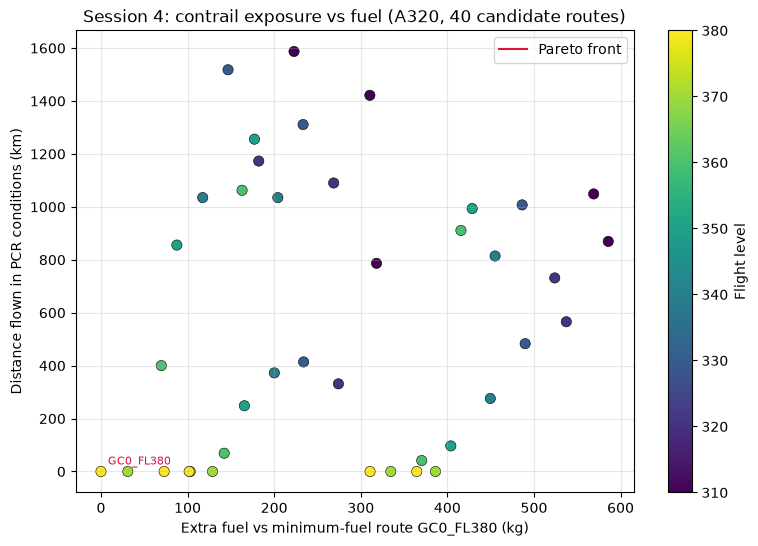

In [9]:
front = m[m["pareto"]].sort_values("fuel_kg")
print("Pareto-optimal routes (no other route has both less fuel and less contrail exposure):")
print(front[["route", "flight_level", "offset_km", "fuel_kg", "extra_fuel_kg",
             "extra_fuel_pct", "extra_co2_kg", "pcr_km", "pcr_km_avoided"]]
      .round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(m["extra_fuel_kg"], m["pcr_km"], c=m["flight_level"],
                cmap="viridis", s=55, edgecolor="k", linewidth=0.4)
ax.step(front["extra_fuel_kg"], front["pcr_km"], where="post", color="crimson",
        linewidth=1.5, label="Pareto front")
for _, r in front.iterrows():
    ax.annotate(r["route"], (r["extra_fuel_kg"], r["pcr_km"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8, color="crimson")
fig.colorbar(sc, label="Flight level")
ax.set_xlabel(f"Extra fuel vs minimum-fuel route {REF} (kg)")
ax.set_ylabel("Distance flown in PCR conditions (km)")
ax.set_title(f"Session 4: contrail exposure vs fuel ({AIRCRAFT}, 40 candidate routes)")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(fig_dir / "session4_pareto_fuel_vs_pcr.png", dpi=150, bbox_inches="tight")
plt.show()

Chosen route as lambda increases (each row = where the choice changes):
 lambda_kg_per_km     route  extra_fuel_kg  pcr_km
              0.0 GC0_FL380            0.0     0.0


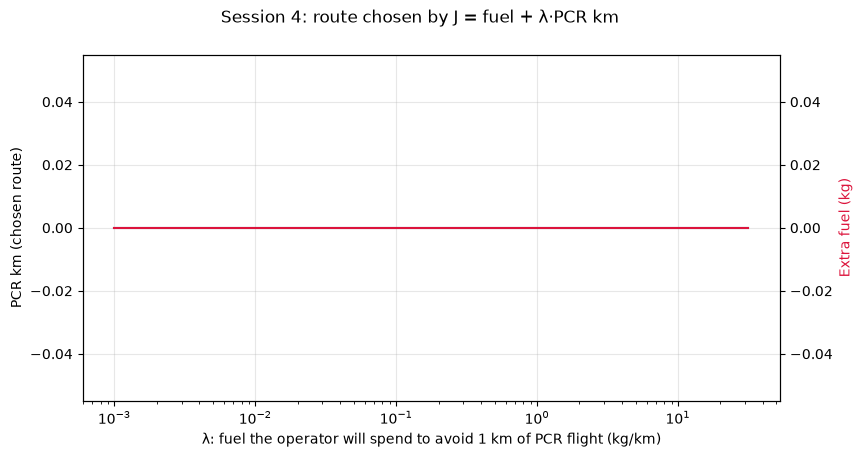

Saved Session 4 results.


In [10]:
# J = fuel_kg + lambda * pcr_km
# lambda = kg of fuel the operator is willing to burn to avoid 1 km of PCR flight
lambdas = np.concatenate([[0.0], np.logspace(-3, 1.5, 300)])
choices = []
for lam in lambdas:
    i = (m["fuel_kg"] + lam * m["pcr_km"]).idxmin()
    choices.append({"lambda_kg_per_km": lam, "route": m.at[i, "route"],
                    "extra_fuel_kg": m.at[i, "extra_fuel_kg"], "pcr_km": m.at[i, "pcr_km"]})
choices = pd.DataFrame(choices)

switches = choices[choices["route"] != choices["route"].shift()]
print("Chosen route as lambda increases (each row = where the choice changes):")
print(switches.round(4).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
c = choices[choices["lambda_kg_per_km"] > 0]
ax1.step(c["lambda_kg_per_km"], c["pcr_km"], where="post", label="PCR km of chosen route")
ax1.set_xscale("log")
ax1.set_xlabel("λ: fuel the operator will spend to avoid 1 km of PCR flight (kg/km)")
ax1.set_ylabel("PCR km (chosen route)")
ax2 = ax1.twinx()
ax2.step(c["lambda_kg_per_km"], c["extra_fuel_kg"], where="post", color="crimson",
         label="Extra fuel of chosen route")
ax2.set_ylabel("Extra fuel (kg)", color="crimson")
ax1.grid(alpha=0.3)
fig.suptitle("Session 4: route chosen by J = fuel + λ·PCR km")
fig.savefig(fig_dir / "session4_lambda_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

m.to_csv(results_dir / "session4_route_metrics.csv", index=False)
choices.to_csv(results_dir / "session4_lambda_choices.csv", index=False)
pd.concat(tables.values(), ignore_index=True).to_csv(
    results_dir / "session4_routes_along_track.csv", index=False)
print("Saved Session 4 results.")

Best options when the aircraft cannot fly above a given flight level:
 ceiling_FL min_fuel_route  its_pcr_km  n_pareto_routes lowest_pcr_route  lowest_pcr_km  extra_fuel_for_lowest_kg  extra_fuel_for_lowest_pct
        310      GC0_FL310      1587.0                3      NW150_FL310          786.6                      95.2                        1.8
        320      GC0_FL320      1173.0                3      NW150_FL320          331.2                      92.0                        1.8
        330      GC0_FL330      1518.0                4      NW150_FL320          331.2                     127.5                        2.4
        340      GC0_FL340      1035.0                4      NW300_FL340          276.0                     332.1                        6.4
        350      GC0_FL350       855.6                3      NW300_FL350           96.6                     316.3                        6.1
        360      GC0_FL360       400.2                3      NW300_FL360           4

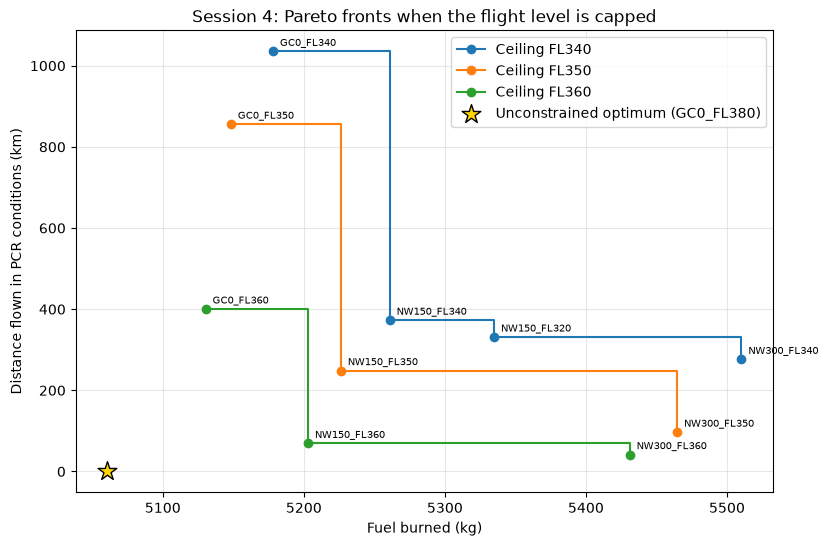

Saved ceiling analysis.


In [11]:
def pareto_with_marginal(sub):
    """Pareto front of a subset, cheapest first, with the marginal fuel cost of each step."""
    f = sub[pareto_mask(sub)].sort_values("fuel_kg").copy()
    f["extra_fuel_vs_min_kg"] = f["fuel_kg"] - f["fuel_kg"].iloc[0]
    f["pcr_avoided_vs_min_km"] = f["pcr_km"].iloc[0] - f["pcr_km"]
    f["marginal_kg_per_km_avoided"] = f["fuel_kg"].diff() / (-f["pcr_km"].diff())
    return f

rows = []
fronts = {}
for ceiling in FLIGHT_LEVELS:
    allowed = m[m["flight_level"] <= ceiling]
    f = pareto_with_marginal(allowed)
    fronts[ceiling] = f
    base, lowest = f.iloc[0], f.iloc[-1]
    rows.append({
        "ceiling_FL": ceiling,
        "min_fuel_route": base["route"],
        "its_pcr_km": base["pcr_km"],
        "n_pareto_routes": len(f),
        "lowest_pcr_route": lowest["route"],
        "lowest_pcr_km": lowest["pcr_km"],
        "extra_fuel_for_lowest_kg": lowest["fuel_kg"] - base["fuel_kg"],
        "extra_fuel_for_lowest_pct": 100 * (lowest["fuel_kg"] - base["fuel_kg"]) / base["fuel_kg"],
    })
ceiling_summary = pd.DataFrame(rows)
print("Best options when the aircraft cannot fly above a given flight level:")
print(ceiling_summary.round(1).to_string(index=False))

show = ["route", "fuel_kg", "pcr_km", "extra_fuel_vs_min_kg",
        "pcr_avoided_vs_min_km", "marginal_kg_per_km_avoided", "rhi_max", "points_rhi_within_0.05"]
for ceiling in [360, 340]:
    print(f"\nPareto front with ceiling FL{ceiling}:")
    print(fronts[ceiling][show].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
for ceiling in [340, 350, 360]:
    f = fronts[ceiling]
    ax.step(f["fuel_kg"], f["pcr_km"], where="post", marker="o", label=f"Ceiling FL{ceiling}")
    for _, r in f.iterrows():
        ax.annotate(r["route"], (r["fuel_kg"], r["pcr_km"]), textcoords="offset points",
                    xytext=(5, 4), fontsize=7)
ax.scatter(m.at[ref_idx, "fuel_kg"], m.at[ref_idx, "pcr_km"], marker="*", s=200,
           color="gold", edgecolor="k", zorder=5, label=f"Unconstrained optimum ({REF})")
ax.set_xlabel("Fuel burned (kg)")
ax.set_ylabel("Distance flown in PCR conditions (km)")
ax.set_title("Session 4: Pareto fronts when the flight level is capped")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(fig_dir / "session4_pareto_by_ceiling.png", dpi=150, bbox_inches="tight")
plt.show()

ceiling_summary.to_csv(results_dir / "session4_ceiling_summary.csv", index=False)
pd.concat([f.assign(ceiling_FL=c) for c, f in fronts.items()]).to_csv(
    results_dir / "session4_pareto_fronts_by_ceiling.csv", index=False)
print("Saved ceiling analysis.")

## Session 4 results

### Setup

40 candidate routes (great circle and ±150/±300 km lateral deviations ×
FL310–FL380) from (−10°, 45°) to (10°, 55°), departing 2022-03-01 00:00 UTC,
were evaluated for persistent-contrail (PCR) exposure and for fuel burn,
using the Poll–Schumann performance model (`PSFlight`) for an A320.
Assumptions: constant true airspeed 230 m/s, no wind, constant flight
level, cruise only, aircraft mass estimated by the model.

**Fuel model check:** the great-circle route at 11,000 m burns 5,129 kg in
130 min (2,359 kg/h, typical of A320 cruise). The aircraft's mass falls by
exactly the fuel burned. Fuel flow is defined per segment, so the final
point has no value by construction. Fuel is summed segment by segment, and
a missing value anywhere else raises an error.

**Code check:** core code moved from notebooks into `src/contrail_routing/`.
A regression test reproduces Session 3's great-circle exposure at 11,000 m
exactly (386.400 km).

### Unconstrained result: no trade-off in this case

The minimum-fuel route is the great circle at FL380 (5,061 kg), and it has
**zero** contrail exposure. On the great circle, fuel falls steadily with
height (+223 kg at FL310 down to 0 at FL380), and the highest levels are
also above the moist layer. The Pareto front is therefore a single route,
and the weighted objective picks it for every λ. For this flight, a
contrail-aware operator and a fuel-only operator would make the same choice.

Caveats:
- FL380 is the top of the grid. ERA5 data was loaded only up to 200 hPa
  (≈FL386), so FL390 was not tested, and fuel was still falling at FL380.
- FL370 and FL380 lie between the 225 and 200 hPa levels, where values are
  interpolated. FL380 has a wide humidity margin (maximum RHi ≈ 0.70);
  FL370's is smaller.

### Constrained result: when the aircraft cannot fly above a given level

Air traffic control, other traffic or aircraft weight can stop an aircraft
reaching its best level. Below FL370, every route has some exposure, and a
real trade-off appears.

| Ceiling | Minimum-fuel route | Its PCR | Lowest-PCR route on the front | Its PCR | Extra fuel |
|---|---|---|---|---|---|
| FL310 | GC0_FL310 | 1,587 km | NW150_FL310 | 787 km | +95 kg (1.8%) |
| FL320 | GC0_FL320 | 1,173 km | NW150_FL320 | 331 km | +92 kg (1.8%) |
| FL330 | GC0_FL330 | 1,518 km | NW150_FL320 | 331 km | +128 kg (2.4%) |
| FL340 | GC0_FL340 | 1,035 km | NW300_FL340 | 276 km | +332 kg (6.4%) |
| FL350 | GC0_FL350 | 856 km | NW300_FL350 | 97 km | +316 kg (6.1%) |
| FL360 | GC0_FL360 | 400 km | NW300_FL360 | 41 km | +301 kg (5.9%) |
| FL370–380 | GC0 | 0 km | (same) | 0 km | 0 |

**Pareto front with a ceiling of FL360:**

| Route | Fuel | PCR | PCR avoided | Extra fuel | Marginal cost |
|---|---|---|---|---|---|
| GC0_FL360 | 5,130 kg | 400 km | — | — | — |
| NW150_FL360 | 5,203 kg | 69 km | 331 km | +73 kg (+1.4%) | 0.22 kg per km avoided |
| NW300_FL360 | 5,431 kg | 41 km | 359 km | +301 kg (+5.9%) | 8.26 kg per km avoided |

**Pareto front with a ceiling of FL340:** GC0_FL340 (1,035 km) →
NW150_FL340 (373 km, +83 kg, 0.12 kg/km) → NW150_FL320 (331 km, +157 kg,
1.79 kg/km) → NW300_FL340 (276 km, +332 kg, 3.18 kg/km).

### Interpretation

- **Avoidance has strongly diminishing returns.** With a ceiling of FL360,
  a 150 km north-west bend removes 83% of contrail exposure for 1.4% extra
  fuel (73 kg, ≈229 kg CO₂). The remaining 28 km cost another 228 kg: a
  marginal cost 37 times higher. At FL340, the first step removes 64% of
  exposure for 1.6% extra fuel.
- **The cheap first step is always a modest bend towards the dry side
  (NW150).** Larger detours buy little extra.
- **The best avoidance option sometimes changes flight level as well as
  path** (e.g. NW150_FL320 under a ceiling of FL330 or FL340). Lower is not
  always worse, because the moist layer is patchy.
- **Choosing between front routes needs a value judgement.** In
  J = fuel + λ·(PCR km), λ is how much fuel the operator will spend to avoid
  1 km of contrail-forming flight. With a ceiling of FL360, NW150_FL360 is
  chosen for λ between 0.22 and 8.26 kg/km, and NW300_FL360 above that.
  Every front's marginal cost rises at each step, so a weighted objective
  can reach every route on these fronts. Turning λ into climate terms would
  need a contrail climate model (e.g. CoCiP) and is left open.
- **Same distance does not mean same fuel.** NW150 and SE150 have identical
  lengths but cost +73 and +102 kg at FL380, because the air temperature
  along each path differs.

### Robustness indications

The cheap options are not equally safe. NW150_FL360 still has 16 points
within ±0.05 of RHi = 1, so its 69 km of exposure could grow under a small
humidity error. The flight-level-ceiling fronts were built from one
deterministic humidity field. Testing whether their ranking survives
humidity uncertainty is the next stage of the project.

### Limitations

- One flight, one date, one departure time; synthetic endpoints.
- No wind, no climb or descent, constant true airspeed (real aircraft
  cruise at constant Mach number).
- Aircraft mass estimated by the model; the optimum level depends on mass.
- Grid limited to FL310–FL380 by the ERA5 levels loaded.
- PCR distance is a proxy for contrail impact, not a climate metric.
- ERA5 humidity, unscaled.